In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact

# ============================================================
# 1. LOAD DATA
# ============================================================

rep_file = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/louvain_by_level_from_table_including_isolates/representatives_by_cluster_level.tsv"
typing_file = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/cell_level/meta/typing.csv"
systems_file = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/louvain_by_level_from_table_including_isolates/defensefinder/defensefinder_all_systems_summary.tsv"

rep = pd.read_csv(rep_file, sep="\t")
typing = pd.read_csv(typing_file)
systems = pd.read_csv(systems_file, sep="\t")

# ============================================================
# 2. DEFINE MULTI VS SINGLE REPLICON
# ============================================================

df = typing[typing["NUCCORE_ACC"].isin(rep["representative"])].copy()

df["rep_count_class"] = np.where(
    df["rep_type(s)"].str.contains(",", na=False),
    "multi_rep",
    "single_rep"
)

df = df[["NUCCORE_ACC", "rep_count_class"]]
df = df.rename(columns={"NUCCORE_ACC": "replicon"})

# ============================================================
# 3. COLLAPSE DEFENSEFINDER TO PRESENCE / ABSENCE PER PLASMID
# ============================================================

presence = (
    systems
    .groupby(["replicon", "activity"])
    .size()
    .unstack(fill_value=0)
)

presence["has_defense"] = presence.get("Defense", 0) > 0
presence["has_antidefense"] = presence.get("Antidefense", 0) > 0

presence = presence.reset_index()[["replicon", "has_defense", "has_antidefense"]]

# Merge
df_full = df.merge(presence, on="replicon", how="left")

df_full["has_defense"] = df_full["has_defense"].fillna(False)
df_full["has_antidefense"] = df_full["has_antidefense"].fillna(False)

# ============================================================
# 4. FUNCTION TO RUN ENRICHMENT TEST
# ============================================================

def enrichment_test(data, column):

    ct = pd.crosstab(data[column], data["rep_count_class"])

    # Ensure full 2x2 table
    for col in ["single_rep", "multi_rep"]:
        if col not in ct.columns:
            ct[col] = 0
    for row in [True, False]:
        if row not in ct.index:
            ct.loc[row] = [0, 0]

    a = ct.loc[True,  "single_rep"]
    b = ct.loc[True,  "multi_rep"]
    c = ct.loc[False, "single_rep"]
    d = ct.loc[False, "multi_rep"]

    chi2, p_chi2, _, _ = chi2_contingency([[a, b], [c, d]])
    or_val, p_fisher = fisher_exact([[a, b], [c, d]])

    return {
        "OR_multi_vs_single": or_val,
        "p_fisher": p_fisher,
        "p_chi2": p_chi2,
        "n_positive": a + b,
        "pct_single": 100 * a / (a + c) if (a + c) > 0 else np.nan,
        "pct_multi": 100 * b / (b + d) if (b + d) > 0 else np.nan
    }

# ============================================================
# 5. RUN TESTS
# ============================================================

res_defense = enrichment_test(df_full, "has_defense")
res_antidef = enrichment_test(df_full, "has_antidefense")

print("\n=== Defense systems enrichment ===")
print(res_defense)

print("\n=== Antidefense systems enrichment ===")
print(res_antidef)



=== Defense systems enrichment ===
{'OR_multi_vs_single': 0.26380052340321697, 'p_fisher': 0.0, 'p_chi2': 0.0, 'n_positive': 11018, 'pct_single': 35.93063019052271, 'pct_multi': 68.00900781560472}

=== Antidefense systems enrichment ===
{'OR_multi_vs_single': 0.22823516471429356, 'p_fisher': 0.0, 'p_chi2': 0.0, 'n_positive': 9939, 'pct_single': 30.41035661944309, 'pct_multi': 65.69081997615578}


/tmp/ipykernel_4133511/1534051171.py:51: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_full["has_defense"] = df_full["has_defense"].fillna(False)
/tmp/ipykernel_4133511/1534051171.py:52: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_full["has_antidefense"] = df_full["has_antidefense"].fillna(False)


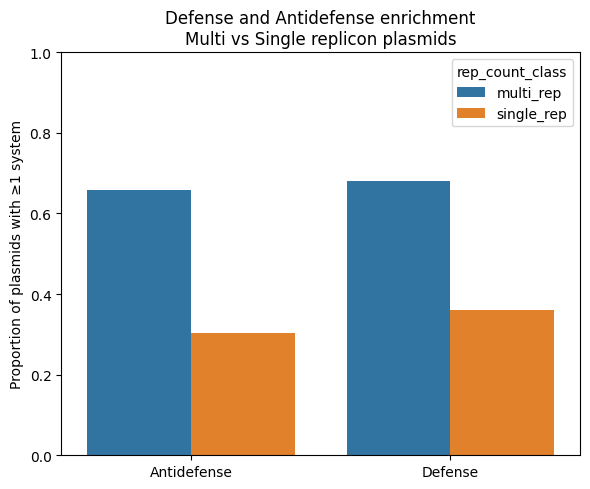

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare long format
plot_df = (
    df_full
    .melt(
        id_vars="rep_count_class",
        value_vars=["has_defense", "has_antidefense"],
        var_name="category",
        value_name="present"
    )
)

# Convert to nicer labels
plot_df["category"] = plot_df["category"].map({
    "has_defense": "Defense",
    "has_antidefense": "Antidefense"
})

# Compute proportions
prop_df = (
    plot_df
    .groupby(["rep_count_class", "category"])["present"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,5))
sns.barplot(
    data=prop_df,
    x="category",
    y="present",
    hue="rep_count_class"
)

plt.ylabel("Proportion of plasmids with ≥1 system")
plt.xlabel("")
plt.ylim(0, 1)
plt.title("Defense and Antidefense enrichment\nMulti vs Single replicon plasmids")
plt.tight_layout()
plt.show()
